Printed Digits Dataset
===

This notebook provides code to generate a printed digits dataset analogous to the MNSIT dataset. The process involves downloading from Google Fonts and writing text to images using the Pillow library.

In [ ]:
from pathlib import Path

data_dir = Path("data")

Fonts
---

See Google's [Developer API](https://developers.google.com/fonts/docs/developer_api#APIKey) for how to generate an API key.

In [ ]:
from getpass import getpass
from pathlib import Path

api_key_path = "google-api-key.txt"
api_doc_url = "https://developers.google.com/fonts/docs/developer_api#APIKey"

try:
    with open(api_key_path, encoding="utf-8") as f:
        key = f.read()
except FileNotFoundError:
    print("Google API key not found."
          f" Please follow {api_doc_url} and enter your API key here: ",
          end="")
    key = getpass()
    with open(api_key_path, "w", encoding="utf-8") as f:
        f.write(key)

Create an API for querying Google Fonts.

In [ ]:
import requests

from enum import Enum
from typing import Optional, TypedDict

class WebfontSort(str, Enum):
    """
    Use None for Trending.
    """
    MOST_POPULAR = "popularity"
    NEWEST = "date"
    NAME = "alpha"

class WebfontItemAxes(TypedDict):
    tag: str
    start: int | float
    end: int | float

class WebfontItems(TypedDict):
    family: str
    variants: list[str]
    subsets: list[str]
    version: str
    lastModified: str
    files: dict[str, str]
    category: str
    kind: str
    menu: str
    axes: list[WebfontItemAxes]

def get_webfonts(sort: Optional[WebfontSort] = None,
                 key: str = key):
    r = requests.get(
        "https://www.googleapis.com/webfonts/v1/webfonts",
        params={
            "key": key,
            "sort": sort
        }
    )
    assert r.status_code == 200
    
    webfonts = r.json()    
    assert webfonts["kind"] == "webfonts#webfontList"

    return webfonts["items"]

Get all fonts by popularity using the API.

In [ ]:
webfont_list = get_webfonts(sort=WebfontSort.MOST_POPULAR)
len(webfont_list)

1603

Note that there are "not text" fonts such as barcode fonts etc. Get the list of those fonts using the metadata and filter them out.

In [ ]:
r = requests.get("https://fonts.google.com/metadata/fonts")
fonts_metadata = r.json()
text_family_set = set(
    font["family"]
    for font in fonts_metadata["familyMetadataList"]
    if "Symbols" not in font["classifications"]
)
text_webfont_list = list(filter(
    lambda font: font["family"] in text_family_set,
    webfont_list
))

len(text_webfont_list)

1579

Asynchronously download the regular variant of all text fonts. Some text fonts doesn't have regular variant, we simply ignore those.

In [ ]:
import asyncio
import aiohttp
import aiofiles

async def download_webfont(session, webfont, root_dir):
    if "regular" not in webfont["files"]:
        return
    ext = webfont["files"]["regular"].rpartition(".")[2]
    path = root_dir / f"{webfont['family']}.{ext}"
    if path.exists():
        return
    async with session.get(webfont["files"]["regular"]) as r:
        if r.status == 200:
            content = await r.read()
            path.parent.mkdir(exist_ok=True)
            async with aiofiles.open(path, "wb") as f:
                await f.write(content)

async def download_webfonts(root: str, webfonts: list):
    root_dir = Path(root)
    root_dir.mkdir(parents=True, exist_ok=True)
    async with aiohttp.ClientSession() as session:
        tasks = [download_webfont(session, webfont, root_dir) for webfont in webfonts]
        await asyncio.gather(*tasks)

webfonts_dir = data_dir / "webfonts"
if not webfonts_dir.exists():
    await download_webfonts(webfonts_dir, text_webfont_list)

Generation
---

In [ ]:
from PIL import Image, ImageDraw, ImageFont
from fontTools.ttLib import TTFont
from matplotlib import font_manager

CLASSES = (
    '0 - zero',
    '1 - one',
    '2 - two',
    '3 - three',
    '4 - four',
    '5 - five',
    '6 - six',
    '7 - seven',
    '8 - eight',
    '9 - nine'
)

def has_glyph(font, glyph):
    for table in TTFont(font)["cmap"].tables:
        if ord(glyph) in table.cmap.keys():
            return True
    return False

def create_printed_digit(font_family: Path | str,
                         digit: int,
                         size=32
                         ) -> Image:
    if not 0 <= digit <= 9:
        raise ValueError("digit must be between 0 and 9 (inclusive)")

    font_path = str(next(webfonts_dir.glob(f"{font_family}.*")))
    if not has_glyph(font_path, str(digit)):
        return None
    try:
        font = ImageFont.truetype(font_path, size)
    except OSError:
        return None

    image = Image.new("L", (size, size))
    draw = ImageDraw.Draw(image)
    try:
        draw.text(
            (size / 2, size / 2),
            str(digit),
            fill=255,
            font=font,
            anchor="mm"
        )
    except OSError:
        return None
    
    return image

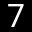

In [ ]:
create_printed_digit("Roboto", 7)

In [ ]:
from tqdm.auto import tqdm

def generate_printed_digit_dataset(root: str,
                                   size: int = 32,
                                   overwrite: bool = False):
    if Path(root).exists() and not overwrite:
        return

    family_list = list(map(lambda path: path.stem, webfonts_dir.glob("*")))
    
    for digit in tqdm(range(10), desc="Digit"):
        class_ = CLASSES[digit]
        Path(root / class_).mkdir(parents=True, exist_ok=True)
        for font_family in tqdm(family_list,
                                desc="Generate",
                                leave=False,
                                unit="font"):
            image = create_printed_digit(font_family, digit, size=size)
            if image is not None:
                image.save(root / class_ / f"{font_family}.png")

In [ ]:
printed_dir = data_dir / "printed"

generate_printed_digit_dataset(printed_dir, overwrite=False)

In [ ]:
printed_32_dir = data_dir / "printed_32x32"

generate_printed_digit_dataset(printed_32_dir, size=32, overwrite=False)

Digit:   0%|          | 0/10 [00:00<?, ?it/s]

Generate:   0%|          | 0/1575 [00:00<?, ?font/s]

Generate:   0%|          | 0/1575 [00:00<?, ?font/s]

Generate:   0%|          | 0/1575 [00:00<?, ?font/s]

Generate:   0%|          | 0/1575 [00:00<?, ?font/s]

...

Generate:   0%|          | 0/1575 [00:00<?, ?font/s]

Generate:   0%|          | 0/1575 [00:00<?, ?font/s]

Generate:   0%|          | 0/1575 [00:00<?, ?font/s]

Generate:   0%|          | 0/1575 [00:00<?, ?font/s]

Generate:   0%|          | 0/1575 [00:00<?, ?font/s]

Transfer
---

In [ ]:
import torch

from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.transforms import (
    Compose,
    Grayscale,
    RandomPerspective,
    ToTensor
)

from utils import get_available_device

BATCH_SIZE = 128
NUM_WORKERS = 0

torch.manual_seed(42)

device = get_available_device()

transform = Compose([
    ToTensor(),
    Grayscale(),
    RandomPerspective(),
])

dataset = ImageFolder(printed_32_dir, transform=transform)
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [0.9, 0.1])
train_dataset.shuffle = True
train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS
)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS
)
classes = dataset.classes

len(train_dataloader), len(test_dataloader), len(classes)

(111, 13, 10)

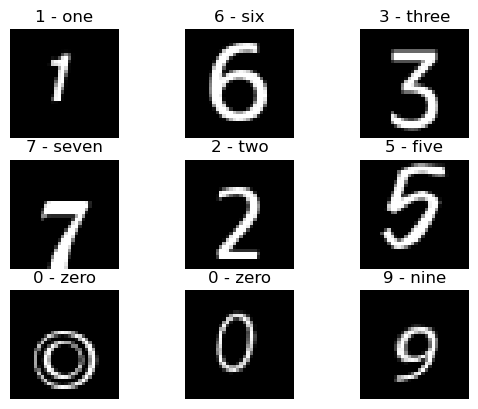

In [ ]:
from utils import plot_dataset_images

plot_dataset_images(dataset)

In [ ]:
import math
from pathlib import Path

from simpnet import SimpnetSlim310K
from train import train_test_loop

SEED = 42

models_dir = Path("models")
name = "simpnet_slim_310k_printed"

simpnet_slim = SimpnetSlim310K(1, len(classes))
state = torch.load(models_dir / "simpnet_slim_310k_emnist.pt")
simpnet_slim.load_state_dict(state)

loss_fn = nn.CrossEntropyLoss()
optimizer = simpnet_slim.get_optimizer(
    torch.optim.RMSprop,
    momentum=0.9,
    eps=math.sqrt(0.001),
    lr=0.00000195,
    weight_decay=0.0981
)

torch.manual_seed(SEED)
train_test_loop(
    simpnet_slim,
    train_dataloader,
    test_dataloader,
    loss_fn,
    optimizer,
    epochs=10,
    save_to=models_dir / f"{name}.pt"
)

  0%|          | 0/10 [00:00<?, ?epoch/s]

Train:   0%|          | 0/111 [00:00<?, ?batch/s]

Test:   0%|          | 0/13 [00:00<?, ?batch/s]

epoch:     1 | train loss: 0.250 | train accuracy: 93.4% | test loss: 0.165 | test accuracy: 96.3%


Train:   0%|          | 0/111 [00:00<?, ?batch/s]

...

Test:   0%|          | 0/13 [00:00<?, ?batch/s]

epoch:     9 | train loss: 0.079 | train accuracy: 98.5% | test loss: 0.087 | test accuracy: 98.4%


Train:   0%|          | 0/111 [00:00<?, ?batch/s]

Test:   0%|          | 0/13 [00:00<?, ?batch/s]

epoch:    10 | train loss: 0.073 | train accuracy: 98.7% | test loss: 0.094 | test accuracy: 97.6%


In [ ]:
import torchvision

from torch import nn

weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
model = torchvision.models.efficientnet_b0(weights=weights).to(device)

for param in model.parameters():
    param.require_grad = False

model.classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1280, len(dataset.classes))
)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

torch.manual_seed(42)
train_test_loop(
    model,
    train_dataloader,
    test_dataloader,
    loss_fn,
    optimizer,
    epochs=5
)

SimpleNet
---

The Printed Digits dataset is a custom dataset very similar to the MNIST handwritten digits dataset, however the digits are generated using fonts instead of handwritten. As a result, the digits are expected to have sharper corners and smoother curves.

### Evaluation without Fine-tuning

Load the Printed Digits dataset. See the [Printed Digits notebook](PrintedDigits.ipynb) on how the data is generated.

In [ ]:
from torchvision.datasets import ImageFolder
from torchvision.transforms import Grayscale, RandomPerspective

from train import test_one_epoch

printed_dir = data_dir / "printed"

torch.manual_seed(SEED)

printed_transform = Compose([
    Resize((32, 32)),
    ToTensor(),
    Grayscale(),
    RandomPerspective()
])

printed_dataset = ImageFolder(printed_dir, transform=printed_transform)
printed_classes = printed_dataset.classes

print(f"Number of samples: {len(printed_dataset)}")
print(f"Number of classes: {len(printed_classes)}")

Number of samples: 15690
Number of classes: 10


Get the accuracy on the entire dataset.

In [ ]:
torch.manual_seed(SEED)
pred_df = prediction_dataframe(
    simpnet_slim,
    printed_dataset,
    printed_classes
)

acc = (pred_df["prediction"] == pred_df["label"]).sum() / len(pred_df)
print(f"Accuracy: {acc}")

Predict:   0%|          | 0/15690 [00:00<?, ?sample/s]

Accuracy: 0.8346080305927343


Visualize the worst predictions as before.

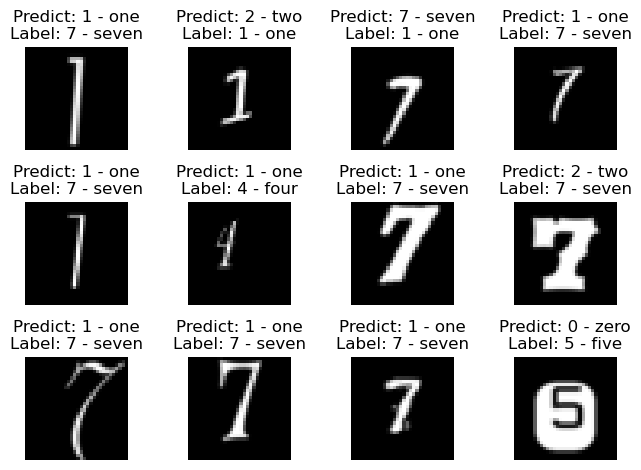

In [ ]:
plot_worst_predictions(pred_df, printed_dataset, n = 12)

### Fine-tuning

There is no separation between training and testing set in the Printed Digits dataset, but PyTorch provides a easy-to-use utility for splitting a dataset into subsets.

In [ ]:
from torch.utils.data import random_split

from torchvision.transforms import Compose, Grayscale, ToTensor, RandomPerspective
from torch import nn
from torchvision.datasets import ImageFolder

printed_simple_transform = Compose([
    ToTensor(),
    Grayscale(),
    RandomPerspective()
])

printed_dataset = ImageFolder(printed_dir, transform=printed_simple_transform)
printed_classes = printed_dataset.classes

generator = torch.Generator().manual_seed(SEED)
printed_train_dataset, printed_test_dataset = random_split(
    printed_dataset,
    [0.9, 0.1],
    generator=generator
)

# number of samples
len(printed_train_dataset), len(printed_test_dataset)

(14121, 1569)

Create data loaders using the training and testing datasets for faster computation in batches.

In [ ]:
BATCH_SIZE = 32

printed_train_dataloader = DataLoader(
    printed_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)
printed_test_dataloader = DataLoader(
    printed_test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS
)

# number of batches
len(printed_train_dataloader), len(printed_test_dataloader)

(442, 50)

Train the model as before with a slower learning rate since there are less samples than before.

In [ ]:
torch.manual_seed(SEED)
pred_df = prediction_dataframe(
    simpnet_slim_printed,
    printed_dataset,
    printed_classes
)
plot_worst_predictions(pred_df, printed_dataset, n = 12)